
# NB-05 · MAE-Style Masked Autoencoding + SegFormer-B0  
## Brain Tumour MRI Binary Semantic Segmentation from COCO Polygons

**Course:** CSE 438: Digital Image Processing  
**Course Instructor:** Dr Md Rifat Ahmmad Rashid  
**Department:** Department of Computer Science and Engineering  
**Institution:** East West University (EWU)

---

### Learning objective

This notebook studies masked-image representation learning before supervised semantic segmentation. It proceeds in two stages:

1. **Masked autoencoding pretraining:** random MRI patches are hidden, and a SegFormer MiT-B0 encoder with a lightweight reconstruction decoder learns to recover the missing image content.
2. **SegFormer fine-tuning:** the same MiT-B0 encoder parameters are transferred directly into `SegformerForSemanticSegmentation` for tumour-region prediction.

The original Masked Autoencoder method was formulated with a patch-token vision transformer. For direct architectural compatibility with SegFormer, this notebook implements an **MAE-style masked reconstruction task on the MiT-B0 encoder itself**. This avoids transferring an unrelated encoder into the downstream segmentation network.

### Dataset convention

The dataset stores tumour boundaries as COCO polygons. All polygons belonging to one MRI are merged into one semantic mask:

\[
0=\text{background}, \qquad 1=\text{tumour region}.
\]

### Computational safety

Only standard contiguous tensors are used. A CUDA execution probe is performed before training. AMP is enabled only when CUDA successfully executes a kernel and backward pass; otherwise, the notebook falls back to CPU with a diagnostic message.



## Pipeline overview

\[
\text{MRI image}
\longrightarrow
\text{random patch masking}
\longrightarrow
\text{MiT-B0 encoder}
\longrightarrow
\text{reconstruction decoder}
\longrightarrow
\text{masked-pixel reconstruction loss}
\]

\[
\text{MAE-trained MiT-B0 encoder}
\longrightarrow
\text{SegFormer-B0 decoder head}
\longrightarrow
\text{binary tumour probability map}
\longrightarrow
\text{semantic mask}
\]


In [1]:

# ============================================================
# 1. Imports, configuration, output directories, and seeding
# ============================================================

from pathlib import Path
from contextlib import nullcontext
import copy
import json
import math
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, Rectangle
from PIL import Image, ImageDraw

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms as T
from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode

from transformers import (
    SegformerConfig,
    SegformerModel,
    SegformerForSemanticSegmentation,
)

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=UserWarning)

# ------------------------------------------------------------
# Required Kaggle source dataset path.
# ------------------------------------------------------------
DATA_ROOT = Path("/kaggle/input/datasets/pkdarabi/brain-tumor-image-dataset-semantic-segmentation")

# ------------------------------------------------------------
# Every experiment artefact is saved under /kaggle/working.
# ------------------------------------------------------------
OUTPUT_DIR = Path("/kaggle/working/mae_segformer_brain_tumour")
FIGURE_DIR = OUTPUT_DIR / "figures"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
METRIC_DIR = OUTPUT_DIR / "metrics"

for directory in [OUTPUT_DIR, FIGURE_DIR, CHECKPOINT_DIR, METRIC_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Core training configuration.
# ------------------------------------------------------------
SEED = 438
IMAGE_SIZE = 224
NUM_CLASSES = 2
MAE_EPOCHS = 10
SEGMENTATION_EPOCHS = 10
NUM_WORKERS = 2

MIT_MODEL_ID = "nvidia/mit-b0"
LOAD_PRETRAINED_MIT_WHEN_AVAILABLE = True

MASK_PATCH_SIZE = 16
MASK_RATIO = 0.60
MAE_LR = 2e-4
SEGMENTATION_LR = 2e-4
WEIGHT_DECAY = 1e-4

def seed_everything(seed=SEED):
    """Control random initialisation, data order, and masking choices."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        try:
            torch.cuda.manual_seed_all(seed)
        except Exception:
            pass

seed_everything()

print(f"Dataset root: {DATA_ROOT}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Torch version: {torch.__version__}")


Dataset root: /kaggle/input/datasets/pkdarabi/brain-tumor-image-dataset-semantic-segmentation
Output directory: /kaggle/working/mae_segformer_brain_tumour
Torch version: 2.10.0+cu128


In [2]:

# ============================================================
# 2. CUDA execution probe and conditional AMP activation
# ============================================================

def select_safe_device():
    """
    Some Kaggle accelerator combinations report CUDA availability while failing
    on executable kernels. A real convolution and backward pass are performed
    before CUDA is accepted for this notebook.
    """
    if not torch.cuda.is_available():
        print("CUDA is unavailable. CPU mode selected; AMP is disabled.")
        return torch.device("cpu"), False

    try:
        probe_input = torch.randn(2, 3, 32, 32, device="cuda", requires_grad=True)
        probe_layer = nn.Conv2d(3, 6, kernel_size=3, padding=1).to("cuda")
        probe_loss = probe_layer(probe_input).square().mean()
        probe_loss.backward()
        torch.cuda.synchronize()
        print(f"CUDA probe passed on {torch.cuda.get_device_name(0)}.")
        print("CUDA mode selected; AMP is enabled for compatible forward passes.")
        return torch.device("cuda"), True
    except Exception as error:
        print("CUDA is visible, but executable kernel validation failed.")
        print(f"Diagnostic message: {type(error).__name__}: {error}")
        print("CPU fallback selected; AMP is disabled.")
        return torch.device("cpu"), False

DEVICE, AMP_ENABLED = select_safe_device()

def autocast_context():
    """Permit mixed precision only after a successful CUDA kernel test."""
    if not AMP_ENABLED:
        return nullcontext()
    try:
        return torch.amp.autocast(device_type="cuda", dtype=torch.float16, enabled=True)
    except AttributeError:
        return torch.cuda.amp.autocast(dtype=torch.float16, enabled=True)

def float32_loss_context(tensor):
    """Keep reconstruction and metric arithmetic in float32 under AMP."""
    if not tensor.is_cuda:
        return nullcontext()
    try:
        return torch.amp.autocast(device_type="cuda", enabled=False)
    except AttributeError:
        return torch.cuda.amp.autocast(enabled=False)

def create_grad_scaler():
    """Retain compatibility across commonly available Kaggle Torch images."""
    try:
        return torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)
    except (AttributeError, TypeError):
        return torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)

MAE_BATCH_SIZE = 16 if DEVICE.type == "cuda" else 4
SEGMENTATION_BATCH_SIZE = 6 if DEVICE.type == "cuda" else 2
PIN_MEMORY = DEVICE.type == "cuda"

print(f"Device: {DEVICE}")
print(f"AMP enabled: {AMP_ENABLED}")
print(f"MAE batch size: {MAE_BATCH_SIZE}; segmentation batch size: {SEGMENTATION_BATCH_SIZE}")


CUDA probe passed on Tesla T4.
CUDA mode selected; AMP is enabled for compatible forward passes.
Device: cuda
AMP enabled: True
MAE batch size: 16; segmentation batch size: 6



## COCO polygon rasterisation

The COCO file may attach several polygon segments to a single MRI. Since the learning task is binary semantic segmentation rather than instance separation, each valid polygon is filled using label `1` in a common mask canvas. Nearest-neighbour interpolation is used whenever a mask is transformed, preserving discrete class values.


In [3]:

# ============================================================
# 3. COCO parsing, binary-mask generation, and data transforms
# ============================================================

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

def normalise_batch(image_batch):
    """Apply ImageNet scaling directly to a BCHW tensor on its current device."""
    mean = image_batch.new_tensor(IMAGENET_MEAN).view(1, 3, 1, 1)
    std = image_batch.new_tensor(IMAGENET_STD).view(1, 3, 1, 1)
    return ((image_batch - mean) / std).contiguous()

def denormalise_image(image_tensor):
    """Convert one normalised CHW image tensor back to a displayable RGB array."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    recovered = image_tensor.detach().cpu() * std + mean
    return recovered.clamp(0, 1).permute(1, 2, 0).numpy()

def load_coco_records(split_directory: Path):
    """Load image metadata and group all COCO annotations by image identifier."""
    annotation_path = split_directory / "_annotations.coco.json"
    if not annotation_path.exists():
        raise FileNotFoundError(f"COCO annotation file not found: {annotation_path}")

    with open(annotation_path, "r", encoding="utf-8") as file:
        coco_data = json.load(file)

    annotations_by_image = {}
    for annotation in coco_data.get("annotations", []):
        annotations_by_image.setdefault(annotation["image_id"], []).append(annotation)

    records = []
    for image_entry in coco_data.get("images", []):
        image_path = split_directory / image_entry["file_name"]
        if not image_path.exists():
            candidate = split_directory / Path(image_entry["file_name"]).name
            image_path = candidate if candidate.exists() else image_path

        if image_path.exists():
            records.append({
                "image_id": image_entry["id"],
                "file_name": image_entry["file_name"],
                "image_path": image_path,
                "annotations": annotations_by_image.get(image_entry["id"], []),
            })

    if not records:
        raise RuntimeError(f"No readable images were found in {split_directory}.")
    return records

def polygons_to_binary_mask(image_size, annotations):
    """
    Rasterise all tumour polygons associated with one image into one mask:
    background = 0, tumour region = 1.
    """
    mask = Image.new("L", image_size, color=0)
    drawer = ImageDraw.Draw(mask)

    for annotation in annotations:
        segmentation = annotation.get("segmentation", [])
        if not isinstance(segmentation, list):
            raise ValueError("The notebook expects polygon COCO segmentations, not RLE.")

        for polygon in segmentation:
            if len(polygon) < 6:
                continue
            vertices = [
                (float(polygon[i]), float(polygon[i + 1]))
                for i in range(0, len(polygon) - 1, 2)
            ]
            drawer.polygon(vertices, outline=1, fill=1)

    return mask

class PairedSegmentationTransform:
    """Apply identical geometric transforms to MRI and semantic mask."""
    def __init__(self, size=IMAGE_SIZE, training=False):
        self.size = size
        self.training = training

    def __call__(self, image, mask):
        if self.training:
            if random.random() < 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)
            if random.random() < 0.20:
                image = TF.vflip(image)
                mask = TF.vflip(mask)

            angle = random.uniform(-10.0, 10.0)
            image = TF.rotate(image, angle, interpolation=InterpolationMode.BILINEAR, fill=0)
            mask = TF.rotate(mask, angle, interpolation=InterpolationMode.NEAREST, fill=0)

        image = TF.resize(image, [self.size, self.size], interpolation=InterpolationMode.BILINEAR)
        mask = TF.resize(mask, [self.size, self.size], interpolation=InterpolationMode.NEAREST)

        image_tensor = normalise_batch(TF.to_tensor(image).unsqueeze(0))[0].contiguous()
        mask_array = np.asarray(mask, dtype=np.int64).copy()
        mask_tensor = torch.from_numpy((mask_array > 0).astype(np.int64)).long().contiguous()
        return image_tensor, mask_tensor

class COCOSemanticDataset(Dataset):
    """Dataset used for labelled SegFormer training and evaluation."""
    def __init__(self, split_directory, training=False):
        self.records = load_coco_records(Path(split_directory))
        self.transform = PairedSegmentationTransform(training=training)

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        record = self.records[index]
        image = Image.open(record["image_path"]).convert("RGB")
        mask = polygons_to_binary_mask(image.size, record["annotations"])
        image_tensor, mask_tensor = self.transform(image, mask)
        return image_tensor, mask_tensor, record["file_name"]

class MAEPretrainingDataset(Dataset):
    """
    Dataset for unlabelled masked reconstruction. It returns an RGB image in
    [0,1]; masking is generated dynamically during each training mini-batch.
    """
    def __init__(self, split_directory, training=True):
        self.records = load_coco_records(Path(split_directory))
        self.training = training

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        image = Image.open(self.records[index]["image_path"]).convert("RGB")

        if self.training:
            if random.random() < 0.5:
                image = TF.hflip(image)
            angle = random.uniform(-8.0, 8.0)
            image = TF.rotate(image, angle, interpolation=InterpolationMode.BILINEAR, fill=0)

        image = TF.resize(image, [IMAGE_SIZE, IMAGE_SIZE], interpolation=InterpolationMode.BILINEAR)
        clean_tensor = TF.to_tensor(image).contiguous()
        return clean_tensor, self.records[index]["file_name"]


In [4]:

# ============================================================
# 4. Datasets, loaders, and annotation-distribution inspection
# ============================================================

if not DATA_ROOT.exists():
    raise FileNotFoundError(
        f"Dataset root not found: {DATA_ROOT}\n"
        "Add the required Kaggle dataset to the notebook before execution."
    )

TRAIN_DIR = DATA_ROOT / "train"
VALID_DIR = DATA_ROOT / "valid"
TEST_DIR = DATA_ROOT / "test"

train_dataset = COCOSemanticDataset(TRAIN_DIR, training=True)
train_display_dataset = COCOSemanticDataset(TRAIN_DIR, training=False)
valid_dataset = COCOSemanticDataset(VALID_DIR, training=False)
test_dataset = COCOSemanticDataset(TEST_DIR, training=False)

mae_dataset = MAEPretrainingDataset(TRAIN_DIR, training=True)
mae_display_dataset = MAEPretrainingDataset(TRAIN_DIR, training=False)

loader_settings = dict(
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=NUM_WORKERS > 0,
)

train_loader = DataLoader(
    train_dataset, batch_size=SEGMENTATION_BATCH_SIZE, shuffle=True,
    drop_last=False, **loader_settings
)
valid_loader = DataLoader(
    valid_dataset, batch_size=SEGMENTATION_BATCH_SIZE, shuffle=False,
    drop_last=False, **loader_settings
)
test_loader = DataLoader(
    test_dataset, batch_size=SEGMENTATION_BATCH_SIZE, shuffle=False,
    drop_last=False, **loader_settings
)
feature_loader = DataLoader(
    valid_dataset, batch_size=SEGMENTATION_BATCH_SIZE, shuffle=False,
    drop_last=False, **loader_settings
)
mae_loader = DataLoader(
    mae_dataset, batch_size=MAE_BATCH_SIZE, shuffle=True,
    drop_last=True, **loader_settings
)

if len(mae_loader) == 0:
    raise RuntimeError("The MAE DataLoader is empty. Reduce MAE_BATCH_SIZE while retaining drop_last=True.")

print(f"Training images:   {len(train_dataset)}")
print(f"Validation images: {len(valid_dataset)}")
print(f"Test images:       {len(test_dataset)}")
print(f"MAE mini-batches per epoch: {len(mae_loader)}")

def measure_mask_distribution(dataset, split_name):
    foreground_pixels = 0
    images_with_foreground = 0
    total_pixels = 0

    for _, mask, _ in tqdm(dataset, desc=f"Analysing {split_name} masks", leave=False):
        pixel_count = int(mask.sum().item())
        foreground_pixels += pixel_count
        images_with_foreground += int(pixel_count > 0)
        total_pixels += int(mask.numel())

    return {
        "split": split_name,
        "images": len(dataset),
        "images_with_tumour": images_with_foreground,
        "tumour_images_percent": 100.0 * images_with_foreground / max(1, len(dataset)),
        "tumour_pixels_percent": 100.0 * foreground_pixels / max(1, total_pixels),
    }

mask_statistics = pd.DataFrame([
    measure_mask_distribution(train_display_dataset, "train"),
    measure_mask_distribution(valid_dataset, "valid"),
    measure_mask_distribution(test_dataset, "test"),
])
mask_statistics.to_csv(METRIC_DIR / "mask_distribution.csv", index=False)
mask_statistics


Training images:   1502
Validation images: 429
Test images:       215
MAE mini-batches per epoch: 93


Analysing train masks:   0%|          | 0/1502 [00:00<?, ?it/s]

Analysing valid masks:   0%|          | 0/429 [00:00<?, ?it/s]

Analysing test masks:   0%|          | 0/215 [00:00<?, ?it/s]

,split,images,images_with_tumour,tumour_images_percent,tumour_pixels_percent
0,train,1502,1501,99.933422,3.710254
1,valid,429,429,100.000000,3.721827
2,test,215,215,100.000000,3.716379


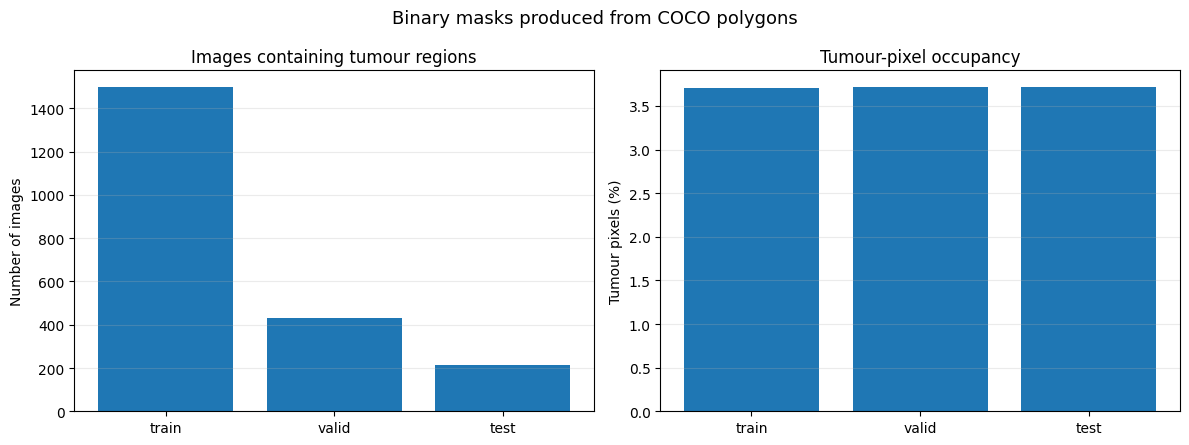

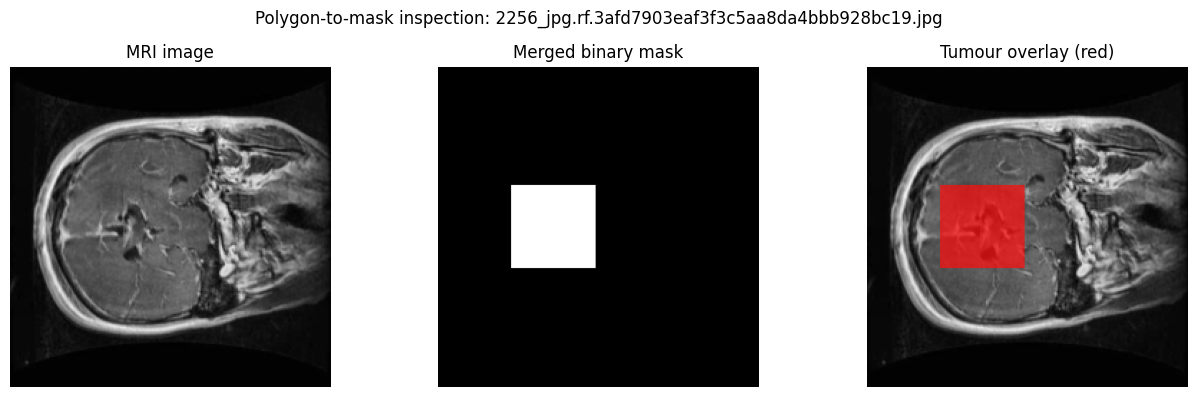

In [5]:

# ============================================================
# 5. COCO-mask verification and preliminary visualisation
# ============================================================

def make_mask_overlay(image_array, mask_array, colour=(1.0, 0.05, 0.05), alpha=0.72):
    """Blend a clearly visible colour inside a binary tumour mask."""
    overlay = image_array.copy()
    region = np.asarray(mask_array).astype(bool)
    if region.any():
        colour_array = np.asarray(colour, dtype=np.float32)
        overlay[region] = (1.0 - alpha) * overlay[region] + alpha * colour_array
    return np.clip(overlay, 0.0, 1.0)

figure, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(mask_statistics["split"], mask_statistics["images_with_tumour"])
axes[0].set_title("Images containing tumour regions")
axes[0].set_ylabel("Number of images")
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(mask_statistics["split"], mask_statistics["tumour_pixels_percent"])
axes[1].set_title("Tumour-pixel occupancy")
axes[1].set_ylabel("Tumour pixels (%)")
axes[1].grid(axis="y", alpha=0.25)

figure.suptitle("Binary masks produced from COCO polygons", fontsize=13)
figure.tight_layout()
figure.savefig(FIGURE_DIR / "01_mask_distribution.png", dpi=180, bbox_inches="tight")
plt.show()

positive_index = next(
    (index for index in range(len(train_display_dataset))
     if train_display_dataset[index][1].sum().item() > 0),
    0,
)

sample_image, sample_mask, sample_name = train_display_dataset[positive_index]
display_image = denormalise_image(sample_image)
mask_array = sample_mask.numpy()
mask_overlay = make_mask_overlay(display_image, mask_array)

figure, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(display_image)
axes[0].set_title("MRI image")
axes[1].imshow(mask_array, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Merged binary mask")
axes[2].imshow(mask_overlay)
axes[2].set_title("Tumour overlay (red)")
for axis in axes:
    axis.axis("off")

figure.suptitle(f"Polygon-to-mask inspection: {sample_name}", fontsize=12)
figure.tight_layout()
figure.savefig(FIGURE_DIR / "02_polygon_mask_overlay.png", dpi=180, bbox_inches="tight")
plt.show()


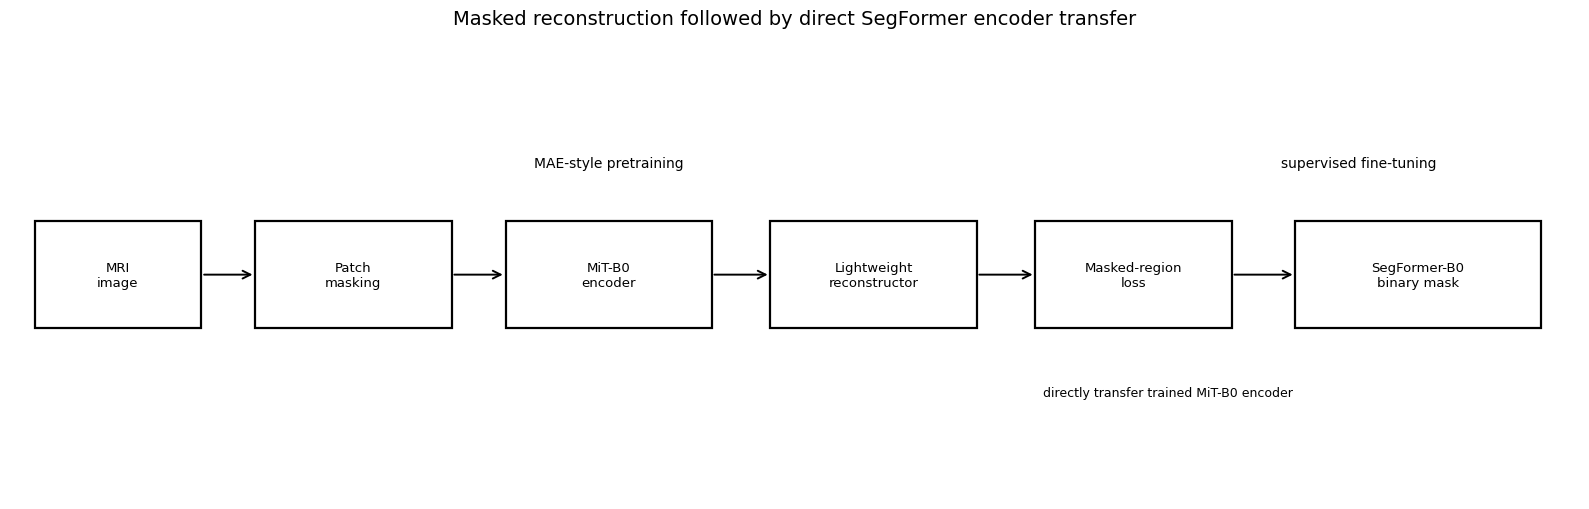

In [6]:

# ============================================================
# 6. Instructional workflow diagram: MAE-style learning to SegFormer
# ============================================================

figure, axis = plt.subplots(figsize=(16, 5.2))
axis.set_xlim(0, 16)
axis.set_ylim(0, 5.2)
axis.axis("off")

diagram_boxes = [
    (0.25, 1.9, 1.7, 1.2, "MRI\nimage"),
    (2.5, 1.9, 2.0, 1.2, "Patch\nmasking"),
    (5.05, 1.9, 2.1, 1.2, "MiT-B0\nencoder"),
    (7.75, 1.9, 2.1, 1.2, "Lightweight\nreconstructor"),
    (10.45, 1.9, 2.0, 1.2, "Masked-region\nloss"),
    (13.1, 1.9, 2.5, 1.2, "SegFormer-B0\nbinary mask"),
]

for x, y, width, height, text in diagram_boxes:
    axis.add_patch(Rectangle((x, y), width, height, fill=False, linewidth=1.6))
    axis.text(x + width / 2, y + height / 2, text, ha="center", va="center", fontsize=9.5)

connections = [
    ((1.95, 2.5), (2.5, 2.5)),
    ((4.5, 2.5), (5.05, 2.5)),
    ((7.15, 2.5), (7.75, 2.5)),
    ((9.85, 2.5), (10.45, 2.5)),
    ((12.45, 2.5), (13.1, 2.5)),
]
for start, finish in connections:
    axis.add_patch(FancyArrowPatch(start, finish, arrowstyle="->", mutation_scale=14, linewidth=1.4))

axis.text(6.10, 3.7, "MAE-style pretraining", ha="center", fontsize=10)
axis.text(13.75, 3.7, "supervised fine-tuning", ha="center", fontsize=10)
axis.text(11.8, 1.15, "directly transfer trained MiT-B0 encoder", ha="center", fontsize=9)

axis.set_title("Masked reconstruction followed by direct SegFormer encoder transfer", fontsize=14)
figure.tight_layout()
figure.savefig(FIGURE_DIR / "03_mae_segformer_workflow.png", dpi=180, bbox_inches="tight")
plt.show()



## MAE-style masked reconstruction using MiT-B0

A binary patch mask \(\mathbf{M}\) hides a proportion of the input MRI. The encoder receives the corrupted input, while the reconstruction decoder predicts an RGB image. The pretraining loss is evaluated only over hidden pixels:

\[
\mathcal{L}_{\mathrm{MAE}}
=
\frac{\left\|\mathbf{M}\odot(\hat{\mathbf{x}}-\mathbf{x})\right\|_2^2}
{\sum \mathbf{M}}.
\]

The masked-only objective discourages the network from solving the task through trivial copying of visible intensities. Because the encoder is MiT-B0, its learned parameters can be inserted directly into SegFormer-B0.


In [7]:

# ============================================================
# 7. MiT-B0 construction with a Kaggle-safe offline fallback
# ============================================================

def mit_b0_fallback_config(num_labels=NUM_CLASSES):
    """Canonical SegFormer-B0 configuration for offline or unavailable checkpoints."""
    return SegformerConfig(
        num_channels=3,
        num_encoder_blocks=4,
        depths=[2, 2, 2, 2],
        sr_ratios=[8, 4, 2, 1],
        hidden_sizes=[32, 64, 160, 256],
        patch_sizes=[7, 3, 3, 3],
        strides=[4, 2, 2, 2],
        num_attention_heads=[1, 2, 5, 8],
        mlp_ratios=[4, 4, 4, 4],
        decoder_hidden_size=256,
        num_labels=num_labels,
        semantic_loss_ignore_index=255,
        id2label={0: "background", 1: "tumour"},
        label2id={"background": 0, "tumour": 1},
    )

def create_initial_mit_encoder():
    """
    Load the published MiT-B0 encoder when files are accessible in Kaggle.
    If network or cached weights are unavailable, preserve the architecture
    by constructing the same MiT-B0 design with random initialisation.
    """
    if LOAD_PRETRAINED_MIT_WHEN_AVAILABLE:
        try:
            encoder = SegformerModel.from_pretrained(MIT_MODEL_ID)
            print(f"Loaded MiT-B0 checkpoint: {MIT_MODEL_ID}")
            return encoder, "pretrained nvidia/mit-b0"
        except Exception as error:
            print(f"MiT-B0 checkpoint was unavailable: {type(error).__name__}: {error}")
            print("Using randomly initialised MiT-B0 while retaining direct transfer compatibility.")

    return SegformerModel(mit_b0_fallback_config()), "randomly initialised MiT-B0"

def final_feature_map(segformer_backbone, pixel_values):
    """
    Obtain the final spatial MiT feature map. Transformer-library versions may
    expose the final state either as BCHW features or as flattened patch tokens.
    """
    output = segformer_backbone(pixel_values=pixel_values, return_dict=True)
    final_state = output.last_hidden_state

    if final_state.ndim == 4:
        return final_state

    if final_state.ndim == 3:
        batch_size, token_count, channels = final_state.shape
        side = int(round(math.sqrt(token_count)))
        if side * side != token_count:
            raise RuntimeError("The final token sequence cannot be mapped to a square feature grid.")
        return final_state.transpose(1, 2).reshape(batch_size, channels, side, side)

    raise RuntimeError(f"Unexpected final encoder-state shape: {tuple(final_state.shape)}")

def pooled_mit_features(segformer_backbone, pixel_values):
    """Produce a fixed-dimensional vector for t-SNE analysis."""
    spatial_features = final_feature_map(segformer_backbone, pixel_values)
    return F.adaptive_avg_pool2d(spatial_features, output_size=1).flatten(1)


In [8]:

# ============================================================
# 8. Patch masking and the MAE-style MiT-B0 reconstruction model
# ============================================================

def random_patch_mask(image_batch, patch_size=MASK_PATCH_SIZE, mask_ratio=MASK_RATIO):
    """
    Generate independent binary patch masks for a batch.
    A value of 1 indicates a hidden pixel used for reconstruction loss.
    """
    batch_size, _, height, width = image_batch.shape
    if height % patch_size != 0 or width % patch_size != 0:
        raise ValueError("IMAGE_SIZE must be divisible by MASK_PATCH_SIZE.")

    grid_height = height // patch_size
    grid_width = width // patch_size
    patch_count = grid_height * grid_width
    hidden_patch_count = int(round(mask_ratio * patch_count))
    hidden_patch_count = min(max(hidden_patch_count, 1), patch_count - 1)

    patch_masks = torch.zeros(batch_size, patch_count, device=image_batch.device)
    for sample_index in range(batch_size):
        hidden_indices = torch.randperm(patch_count, device=image_batch.device)[:hidden_patch_count]
        patch_masks[sample_index, hidden_indices] = 1.0

    patch_masks = patch_masks.view(batch_size, 1, grid_height, grid_width)
    pixel_masks = patch_masks.repeat_interleave(patch_size, dim=2).repeat_interleave(patch_size, dim=3)
    return pixel_masks.contiguous()

class MAESegFormerEncoder(nn.Module):
    """
    Compatibility-preserving masked autoencoder:
      encoder: MiT-B0, later transferred directly into SegFormer;
      decoder: lightweight upsampling reconstruction branch, discarded after pretraining.
    """
    def __init__(self):
        super().__init__()
        self.encoder, self.initialisation_source = create_initial_mit_encoder()
        final_channels = self.encoder.config.hidden_sizes[-1]

        # MiT-B0 reduces a 224 x 224 image to a final 7 x 7 feature map.
        # Five x2 decoding stages restore the original spatial resolution.
        self.reconstruction_decoder = nn.Sequential(
            nn.ConvTranspose2d(final_channels, 192, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(192),
            nn.GELU(),
            nn.ConvTranspose2d(192, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.GELU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.GELU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.GELU(),
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, masked_pixel_values):
        feature_grid = final_feature_map(self.encoder, masked_pixel_values)
        reconstructed = self.reconstruction_decoder(feature_grid)
        if reconstructed.shape[-2:] != masked_pixel_values.shape[-2:]:
            reconstructed = F.interpolate(
                reconstructed, size=masked_pixel_values.shape[-2:],
                mode="bilinear", align_corners=False
            )
        return reconstructed.contiguous()

def masked_reconstruction_loss(reconstruction, clean_target, pixel_mask):
    """Calculate mean squared reconstruction error over hidden patches only."""
    with float32_loss_context(reconstruction):
        squared_error = (reconstruction.float() - clean_target.float()).pow(2)
        masked_squared_error = squared_error * pixel_mask.float()
        normaliser = pixel_mask.sum().float() * clean_target.shape[1] + 1e-7
        return masked_squared_error.sum() / normaliser


In [9]:

# ============================================================
# 9. MAE forward/backward smoke test and ten-epoch pretraining
# ============================================================

mae_model = MAESegFormerEncoder().to(DEVICE)
print(f"Encoder initialisation: {mae_model.initialisation_source}")

# Preserve initial encoder parameters for later representation comparison.
initial_encoder_state = copy.deepcopy(mae_model.encoder.state_dict())
torch.save(initial_encoder_state, CHECKPOINT_DIR / "initial_mit_b0_encoder.pth")

mae_optimizer = torch.optim.AdamW(
    mae_model.parameters(), lr=MAE_LR, weight_decay=WEIGHT_DECAY
)
mae_scaler = create_grad_scaler()

# ------------------------------------------------------------
# Smoke test includes backward propagation before the full loop.
# ------------------------------------------------------------
smoke_clean, _ = next(iter(mae_loader))
smoke_clean = smoke_clean.to(DEVICE, non_blocking=PIN_MEMORY).contiguous()
smoke_mask = random_patch_mask(smoke_clean)
smoke_masked = smoke_clean * (1.0 - smoke_mask)
smoke_input = normalise_batch(smoke_masked)

mae_model.train()
mae_optimizer.zero_grad(set_to_none=True)
with autocast_context():
    smoke_reconstruction = mae_model(smoke_input)
smoke_loss = masked_reconstruction_loss(smoke_reconstruction, smoke_clean, smoke_mask)

assert smoke_loss.dtype == torch.float32, "Masked reconstruction loss must remain float32."
assert torch.isfinite(smoke_loss).item(), "MAE smoke test returned a non-finite loss."

mae_scaler.scale(smoke_loss).backward()
mae_scaler.step(mae_optimizer)
mae_scaler.update()
print(f"MAE forward/backward smoke test passed: reconstruction loss={smoke_loss.item():.5f}")

# Restore initial encoder state after the smoke test so recorded training begins
# from the intended initial checkpoint; reinitialise decoder through model reload.
mae_model = MAESegFormerEncoder().to(DEVICE)
mae_model.encoder.load_state_dict(initial_encoder_state)
mae_optimizer = torch.optim.AdamW(
    mae_model.parameters(), lr=MAE_LR, weight_decay=WEIGHT_DECAY
)
mae_scaler = create_grad_scaler()

mae_history = []

for epoch in range(1, MAE_EPOCHS + 1):
    mae_model.train()
    epoch_losses = []

    progress = tqdm(mae_loader, desc=f"MAE epoch {epoch:02d}/{MAE_EPOCHS}", leave=True)
    for clean_images, _ in progress:
        clean_images = clean_images.to(DEVICE, non_blocking=PIN_MEMORY).contiguous()
        pixel_mask = random_patch_mask(clean_images)
        masked_images = clean_images * (1.0 - pixel_mask)
        model_input = normalise_batch(masked_images)

        mae_optimizer.zero_grad(set_to_none=True)
        with autocast_context():
            reconstructed_images = mae_model(model_input)
        loss = masked_reconstruction_loss(reconstructed_images, clean_images, pixel_mask)

        mae_scaler.scale(loss).backward()
        mae_scaler.step(mae_optimizer)
        mae_scaler.update()

        epoch_losses.append(float(loss.detach().cpu()))
        progress.set_postfix(loss=f"{np.mean(epoch_losses):.5f}")

    mae_history.append({
        "epoch": epoch,
        "masked_reconstruction_loss": float(np.mean(epoch_losses)),
    })

mae_history_df = pd.DataFrame(mae_history)
mae_history_df.to_csv(METRIC_DIR / "mae_pretraining_history.csv", index=False)

torch.save(
    {
        "encoder_state_dict": mae_model.encoder.state_dict(),
        "decoder_state_dict": mae_model.reconstruction_decoder.state_dict(),
        "initialisation_source": mae_model.initialisation_source,
        "mask_ratio": MASK_RATIO,
        "patch_size": MASK_PATCH_SIZE,
        "epochs": MAE_EPOCHS,
    },
    CHECKPOINT_DIR / "mae_mit_b0_encoder.pth",
)

mae_history_df


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/14.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

SegformerModel LOAD REPORT from: nvidia/mit-b0
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded MiT-B0 checkpoint: nvidia/mit-b0
Encoder initialisation: pretrained nvidia/mit-b0


...

MAE epoch 07/10:   0%|          | 0/93 [00:00<?, ?it/s]

MAE epoch 08/10:   0%|          | 0/93 [00:00<?, ?it/s]

MAE epoch 09/10:   0%|          | 0/93 [00:00<?, ?it/s]

MAE epoch 10/10:   0%|          | 0/93 [00:00<?, ?it/s]

,epoch,masked_reconstruction_loss
0,1,0.081515
1,2,0.027531
2,3,0.020246
3,4,0.017818
4,5,0.016169
5,6,0.015060
6,7,0.014470
7,8,0.013783
8,9,0.013404
9,10,0.013073


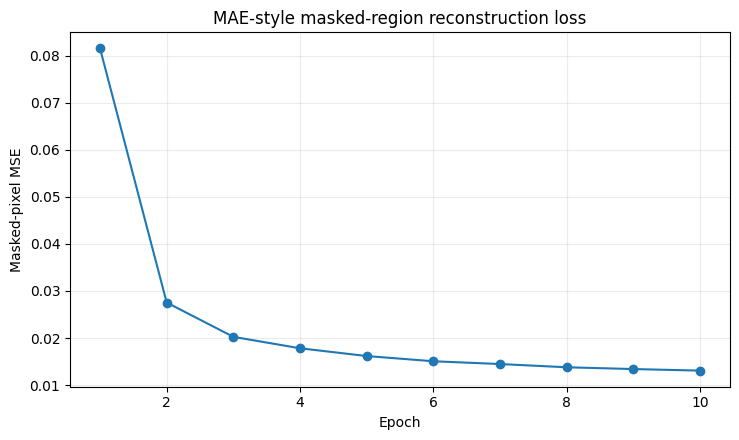

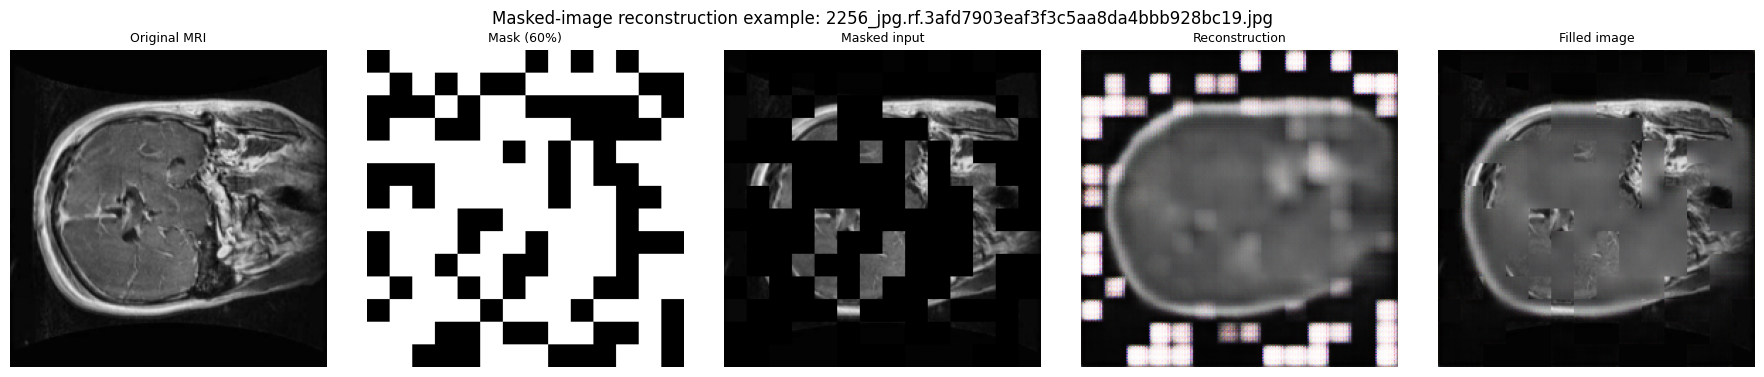

In [10]:

# ============================================================
# 10. MAE reconstruction curves and visual reconstruction inspection
# ============================================================

figure, axis = plt.subplots(figsize=(7.5, 4.5))
axis.plot(
    mae_history_df["epoch"],
    mae_history_df["masked_reconstruction_loss"],
    marker="o",
)
axis.set_title("MAE-style masked-region reconstruction loss")
axis.set_xlabel("Epoch")
axis.set_ylabel("Masked-pixel MSE")
axis.grid(alpha=0.25)
figure.tight_layout()
figure.savefig(FIGURE_DIR / "04_mae_reconstruction_curve.png", dpi=180, bbox_inches="tight")
plt.show()

mae_model.eval()
display_clean, display_name = mae_display_dataset[positive_index]
display_clean_batch = display_clean.unsqueeze(0).to(DEVICE).contiguous()
display_pixel_mask = random_patch_mask(display_clean_batch)
display_masked = display_clean_batch * (1.0 - display_pixel_mask)

with torch.inference_mode():
    with autocast_context():
        display_reconstruction = mae_model(normalise_batch(display_masked))

display_clean_array = display_clean_batch[0].cpu().permute(1, 2, 0).numpy()
display_masked_array = display_masked[0].cpu().permute(1, 2, 0).numpy()
display_reconstructed_array = display_reconstruction[0].float().cpu().permute(1, 2, 0).numpy()
display_mask_array = display_pixel_mask[0, 0].cpu().numpy()

# The composite preserves visible pixels and fills only hidden locations with reconstructions.
display_composite = (
    display_clean_array * (1.0 - display_mask_array[..., None])
    + display_reconstructed_array * display_mask_array[..., None]
)

figure, axes = plt.subplots(1, 5, figsize=(18, 3.8))
panels = [
    (display_clean_array, "Original MRI", None),
    (display_mask_array, f"Mask ({MASK_RATIO:.0%})", "gray"),
    (display_masked_array, "Masked input", None),
    (display_reconstructed_array, "Reconstruction", None),
    (display_composite, "Filled image", None),
]
for axis, (content, title, colourmap) in zip(axes, panels):
    if colourmap is None:
        axis.imshow(np.clip(content, 0, 1))
    else:
        axis.imshow(content, cmap=colourmap, vmin=0, vmax=1)
    axis.set_title(title, fontsize=9)
    axis.axis("off")

figure.suptitle(f"Masked-image reconstruction example: {display_name}", fontsize=12)
figure.tight_layout()
figure.savefig(FIGURE_DIR / "05_mae_reconstruction_example.png", dpi=180, bbox_inches="tight")
plt.show()



## Transfer to SegFormer-B0

After reconstruction pretraining, only the MiT-B0 encoder is retained. The reconstruction decoder is removed from the downstream task. A two-class SegFormer model is created, and the MAE-trained encoder is copied directly into its `segformer` backbone. The output logits are bilinearly upsampled to the ground-truth mask resolution before calculation of loss and evaluation metrics.


In [11]:

# ============================================================
# 11. Direct MiT-B0 transfer and segmentation loss/metrics
# ============================================================

def create_segmentation_model_from_mae(trained_mae_model):
    """Transfer the same MiT-B0 encoder used in masked reconstruction to SegFormer."""
    segmentation_config = copy.deepcopy(trained_mae_model.encoder.config)
    segmentation_config.num_labels = NUM_CLASSES
    segmentation_config.semantic_loss_ignore_index = 255
    segmentation_config.id2label = {0: "background", 1: "tumour"}
    segmentation_config.label2id = {"background": 0, "tumour": 1}

    model = SegformerForSemanticSegmentation(segmentation_config)
    transfer_message = model.segformer.load_state_dict(
        trained_mae_model.encoder.state_dict(), strict=True
    )
    print("MAE-trained MiT-B0 encoder transferred directly into SegFormer-B0.")
    print(transfer_message)
    return model

segmentation_model = create_segmentation_model_from_mae(mae_model).to(DEVICE)

class CrossEntropyForegroundDiceLoss(nn.Module):
    """Use cross-entropy for class prediction and Dice loss for tumour overlap."""
    def __init__(self, dice_weight=1.0, epsilon=1e-6):
        super().__init__()
        self.dice_weight = dice_weight
        self.epsilon = epsilon

    def forward(self, logits, targets):
        cross_entropy = F.cross_entropy(logits, targets)
        foreground_probability = torch.softmax(logits.float(), dim=1)[:, 1]
        foreground_target = (targets == 1).float()

        intersection = (foreground_probability * foreground_target).sum(dim=(1, 2))
        denominator = foreground_probability.sum(dim=(1, 2)) + foreground_target.sum(dim=(1, 2))
        dice = (2.0 * intersection + self.epsilon) / (denominator + self.epsilon)
        dice_loss = 1.0 - dice.mean()

        return cross_entropy + self.dice_weight * dice_loss

criterion = CrossEntropyForegroundDiceLoss(dice_weight=1.0)
segmentation_optimizer = torch.optim.AdamW(
    segmentation_model.parameters(),
    lr=SEGMENTATION_LR,
    weight_decay=WEIGHT_DECAY,
)
segmentation_scaler = create_grad_scaler()

def count_segmentation_outcomes(predictions, targets):
    """Accumulate foreground confusion terms and whole-image correct pixels."""
    predicted_foreground = predictions == 1
    target_foreground = targets == 1

    true_positive = int((predicted_foreground & target_foreground).sum().item())
    false_positive = int((predicted_foreground & ~target_foreground).sum().item())
    false_negative = int((~predicted_foreground & target_foreground).sum().item())
    correctly_classified = int((predictions == targets).sum().item())
    total_pixels = int(targets.numel())

    return true_positive, false_positive, false_negative, correctly_classified, total_pixels

def calculate_metrics(tp, fp, fn, correct, total, epsilon=1e-7):
    return {
        "dice": (2.0 * tp + epsilon) / (2.0 * tp + fp + fn + epsilon),
        "iou": (tp + epsilon) / (tp + fp + fn + epsilon),
        "pixel_accuracy": correct / max(total, 1),
    }

def run_segmentation_epoch(model, loader, optimizer=None, scaler=None, description="evaluation"):
    training = optimizer is not None
    model.train(training)

    losses = []
    tp = fp = fn = correct = total = 0

    progress = tqdm(loader, desc=description, leave=False)
    for images, masks, _ in progress:
        images = images.to(DEVICE, non_blocking=PIN_MEMORY).contiguous()
        masks = masks.to(DEVICE, non_blocking=PIN_MEMORY).contiguous()

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            with autocast_context():
                output = model(pixel_values=images, return_dict=True)
                logits = F.interpolate(
                    output.logits,
                    size=masks.shape[-2:],
                    mode="bilinear",
                    align_corners=False,
                )
                loss = criterion(logits, masks)

            if training:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

        losses.append(float(loss.detach().cpu()))
        predictions = logits.detach().argmax(dim=1)
        batch_counts = count_segmentation_outcomes(predictions, masks.detach())
        tp += batch_counts[0]
        fp += batch_counts[1]
        fn += batch_counts[2]
        correct += batch_counts[3]
        total += batch_counts[4]

        progress.set_postfix(loss=f"{np.mean(losses):.4f}")

    metrics = calculate_metrics(tp, fp, fn, correct, total)
    metrics["loss"] = float(np.mean(losses))
    return metrics


MAE-trained MiT-B0 encoder transferred directly into SegFormer-B0.
<All keys matched successfully>


In [12]:

# ============================================================
# 12. Ten-epoch SegFormer fine-tuning and held-out test evaluation
# ============================================================

segmentation_history = []
best_validation_dice = -1.0
best_checkpoint_path = CHECKPOINT_DIR / "best_mae_segformer_binary_segmentation.pth"

for epoch in range(1, SEGMENTATION_EPOCHS + 1):
    training_metrics = run_segmentation_epoch(
        segmentation_model,
        train_loader,
        optimizer=segmentation_optimizer,
        scaler=segmentation_scaler,
        description=f"SegFormer train {epoch:02d}/{SEGMENTATION_EPOCHS}",
    )
    validation_metrics = run_segmentation_epoch(
        segmentation_model,
        valid_loader,
        description=f"SegFormer valid {epoch:02d}/{SEGMENTATION_EPOCHS}",
    )

    record = {"epoch": epoch}
    for key, value in training_metrics.items():
        record[f"train_{key}"] = value
    for key, value in validation_metrics.items():
        record[f"valid_{key}"] = value
    segmentation_history.append(record)

    print(
        f"Epoch {epoch:02d}: "
        f"train loss={training_metrics['loss']:.4f}, train Dice={training_metrics['dice']:.4f} | "
        f"valid loss={validation_metrics['loss']:.4f}, valid Dice={validation_metrics['dice']:.4f}, "
        f"valid IoU={validation_metrics['iou']:.4f}, "
        f"valid accuracy={validation_metrics['pixel_accuracy']:.4f}"
    )

    if validation_metrics["dice"] > best_validation_dice:
        best_validation_dice = validation_metrics["dice"]
        torch.save(
            {
                "model_state_dict": segmentation_model.state_dict(),
                "epoch": epoch,
                "validation_metrics": validation_metrics,
                "encoder_source": "MAE-style trained MiT-B0 encoder",
            },
            best_checkpoint_path,
        )

segmentation_history_df = pd.DataFrame(segmentation_history)
segmentation_history_df.to_csv(METRIC_DIR / "segformer_training_history.csv", index=False)

best_checkpoint = torch.load(best_checkpoint_path, map_location=DEVICE)
segmentation_model.load_state_dict(best_checkpoint["model_state_dict"])

test_metrics = run_segmentation_epoch(
    segmentation_model, test_loader, description="Held-out test evaluation"
)
test_metrics_df = pd.DataFrame([test_metrics])
test_metrics_df.to_csv(METRIC_DIR / "test_metrics.csv", index=False)

print("\nHeld-out test results from the best validation checkpoint")
print(test_metrics_df.round(4).to_string(index=False))
print(f"\nSaved checkpoint: {best_checkpoint_path}")


SegFormer train 01/10:   0%|          | 0/251 [00:00<?, ?it/s]

SegFormer valid 01/10:   0%|          | 0/72 [00:00<?, ?it/s]

Epoch 01: train loss=0.7204, train Dice=0.5312 | valid loss=0.4215, valid Dice=0.6897, valid IoU=0.5263, valid accuracy=0.9771


SegFormer train 02/10:   0%|          | 0/251 [00:00<?, ?it/s]

SegFormer valid 02/10:   0%|          | 0/72 [00:00<?, ?it/s]

...

SegFormer train 10/10:   0%|          | 0/251 [00:00<?, ?it/s]

SegFormer valid 10/10:   0%|          | 0/72 [00:00<?, ?it/s]

Epoch 10: train loss=0.2940, train Dice=0.7793 | valid loss=0.3046, valid Dice=0.7774, valid IoU=0.6358, valid accuracy=0.9834


Held-out test evaluation:   0%|          | 0/36 [00:00<?, ?it/s]


Held-out test results from the best validation checkpoint
  dice    iou  pixel_accuracy   loss
0.7715 0.6279          0.9832 0.3128

Saved checkpoint: /kaggle/working/mae_segformer_brain_tumour/checkpoints/best_mae_segformer_binary_segmentation.pth


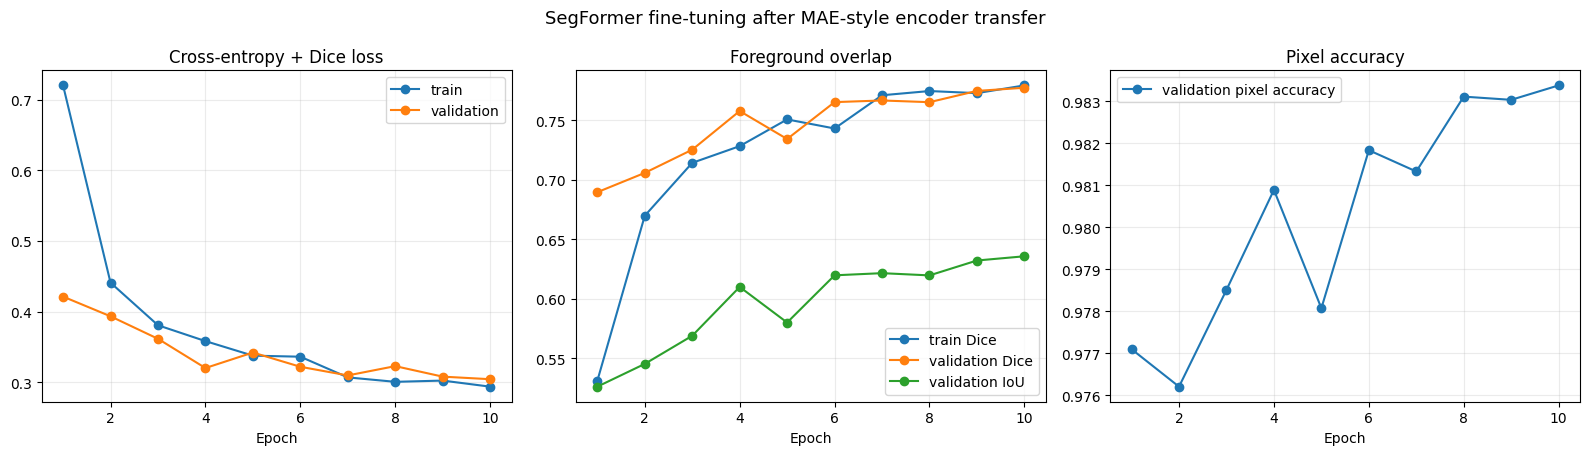

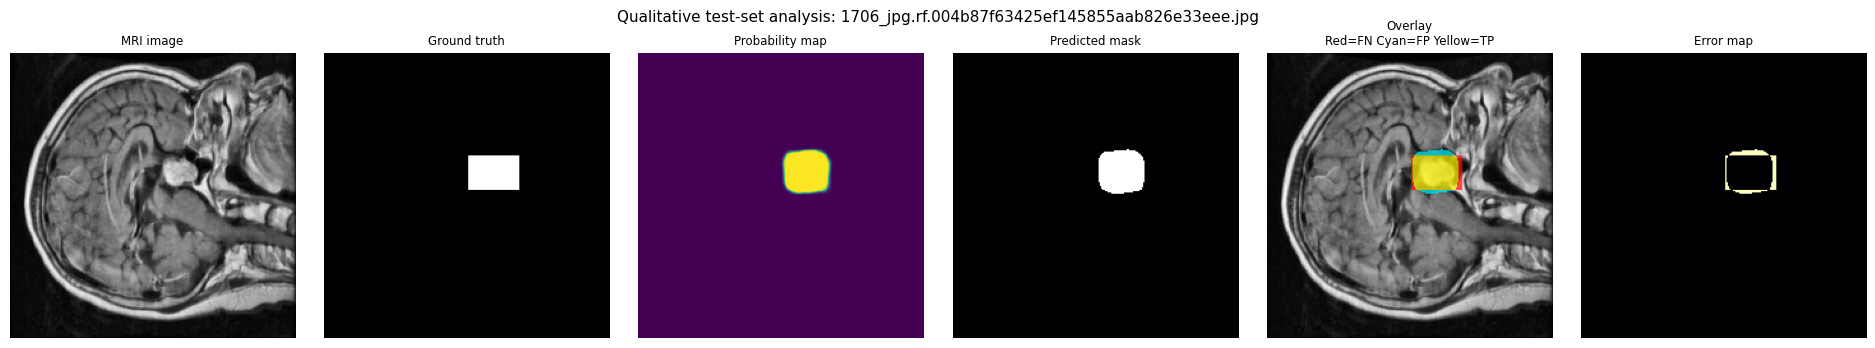

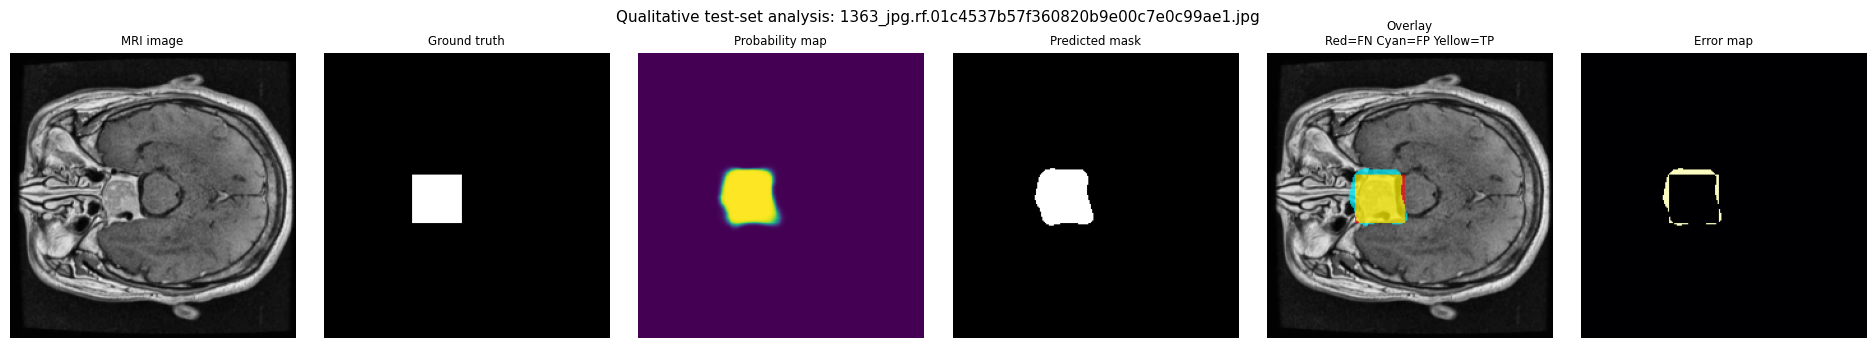

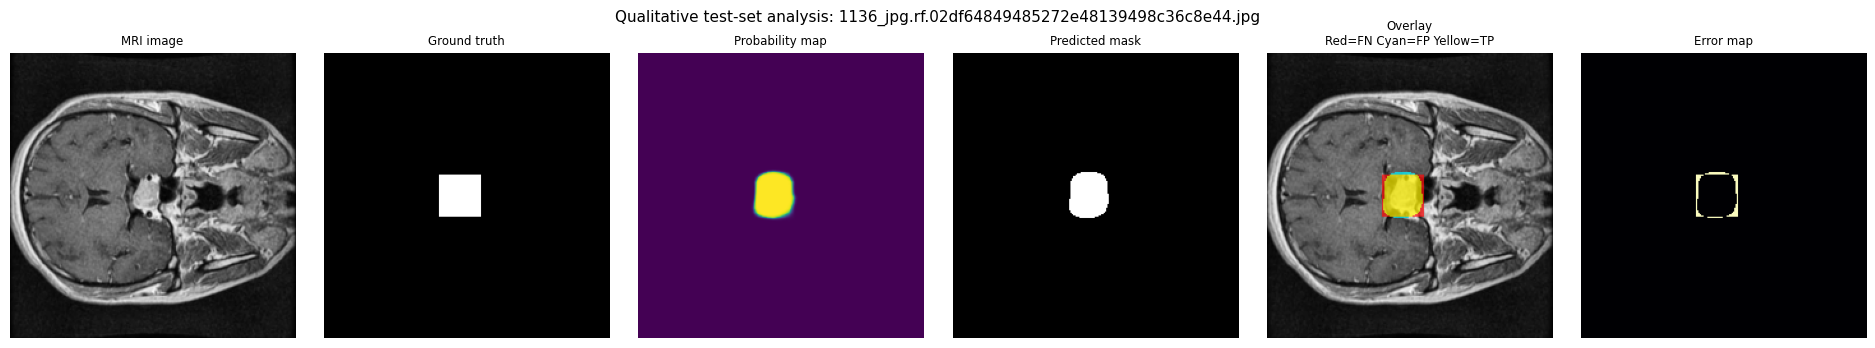

In [13]:

# ============================================================
# 13. Segmentation training curves and qualitative interpretation panels
# ============================================================

figure, axes = plt.subplots(1, 3, figsize=(16, 4.6))

axes[0].plot(segmentation_history_df["epoch"], segmentation_history_df["train_loss"], marker="o", label="train")
axes[0].plot(segmentation_history_df["epoch"], segmentation_history_df["valid_loss"], marker="o", label="validation")
axes[0].set_title("Cross-entropy + Dice loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(segmentation_history_df["epoch"], segmentation_history_df["train_dice"], marker="o", label="train Dice")
axes[1].plot(segmentation_history_df["epoch"], segmentation_history_df["valid_dice"], marker="o", label="validation Dice")
axes[1].plot(segmentation_history_df["epoch"], segmentation_history_df["valid_iou"], marker="o", label="validation IoU")
axes[1].set_title("Foreground overlap")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(alpha=0.25)

axes[2].plot(
    segmentation_history_df["epoch"],
    segmentation_history_df["valid_pixel_accuracy"],
    marker="o",
    label="validation pixel accuracy",
)
axes[2].set_title("Pixel accuracy")
axes[2].set_xlabel("Epoch")
axes[2].legend()
axes[2].grid(alpha=0.25)

figure.suptitle("SegFormer fine-tuning after MAE-style encoder transfer", fontsize=13)
figure.tight_layout()
figure.savefig(FIGURE_DIR / "06_segmentation_training_curves.png", dpi=180, bbox_inches="tight")
plt.show()

@torch.inference_mode()
def predict_one_sample(model, dataset, index):
    image, ground_truth, file_name = dataset[index]
    input_batch = image.unsqueeze(0).to(DEVICE).contiguous()

    with autocast_context():
        output = model(pixel_values=input_batch, return_dict=True)
        logits = F.interpolate(
            output.logits,
            size=ground_truth.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )

    tumour_probability = torch.softmax(logits.float(), dim=1)[0, 1].cpu()
    predicted_mask = (tumour_probability >= 0.5).long()
    return image, ground_truth, tumour_probability, predicted_mask, file_name

def make_comparison_overlay(image_array, ground_truth_array, predicted_array, alpha=0.72):
    """
    Overlay coding:
      yellow = true-positive tumour overlap,
      red    = missed ground-truth tumour pixels,
      cyan   = predicted-only false-positive pixels.
    """
    overlay = image_array.copy()
    truth = np.asarray(ground_truth_array).astype(bool)
    prediction = np.asarray(predicted_array).astype(bool)

    regions_and_colours = [
        (truth & ~prediction, np.array([1.0, 0.05, 0.05], dtype=np.float32)),
        (~truth & prediction, np.array([0.0, 0.95, 1.0], dtype=np.float32)),
        (truth & prediction, np.array([1.0, 0.95, 0.0], dtype=np.float32)),
    ]

    for region, colour in regions_and_colours:
        if region.any():
            overlay[region] = (1.0 - alpha) * overlay[region] + alpha * colour
    return np.clip(overlay, 0.0, 1.0)

positive_test_indices = [
    index for index in range(len(test_dataset))
    if test_dataset[index][1].sum().item() > 0
][:3]
if not positive_test_indices:
    positive_test_indices = list(range(min(3, len(test_dataset))))

for example_number, index in enumerate(positive_test_indices, start=1):
    image, truth, probability, prediction, file_name = predict_one_sample(
        segmentation_model, test_dataset, index
    )

    image_array = denormalise_image(image)
    truth_array = truth.numpy()
    probability_array = probability.numpy()
    prediction_array = prediction.numpy()
    overlay = make_comparison_overlay(image_array, truth_array, prediction_array)
    error_map = (truth != prediction).numpy().astype(float)

    figure, axes = plt.subplots(1, 6, figsize=(19, 3.5))
    panels = [
        (image_array, "MRI image", None),
        (truth_array, "Ground truth", "gray"),
        (probability_array, "Probability map", "viridis"),
        (prediction_array, "Predicted mask", "gray"),
        (overlay, "Overlay\nRed=FN Cyan=FP Yellow=TP", None),
        (error_map, "Error map", "magma"),
    ]

    for axis, (panel, title, colourmap) in zip(axes, panels):
        if colourmap is None:
            axis.imshow(panel)
        else:
            axis.imshow(panel, cmap=colourmap, vmin=0, vmax=1)
        axis.set_title(title, fontsize=8.5)
        axis.axis("off")

    figure.suptitle(f"Qualitative test-set analysis: {file_name}", fontsize=11)
    figure.tight_layout()
    figure.savefig(
        FIGURE_DIR / f"07_prediction_example_{example_number}.png",
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()



## Feature-space and spatial-response analysis

Three representations are compared:

1. **Before masked reconstruction:** the initial MiT-B0 encoder.
2. **After masked reconstruction:** the encoder after ten MAE-style epochs.
3. **After supervised fine-tuning:** the encoder within the final SegFormer model.

The response maps visualise mean feature activation over spatial locations. The t-SNE plots show local feature neighbourhoods and are intended for interpretation rather than as standalone quantitative evidence.


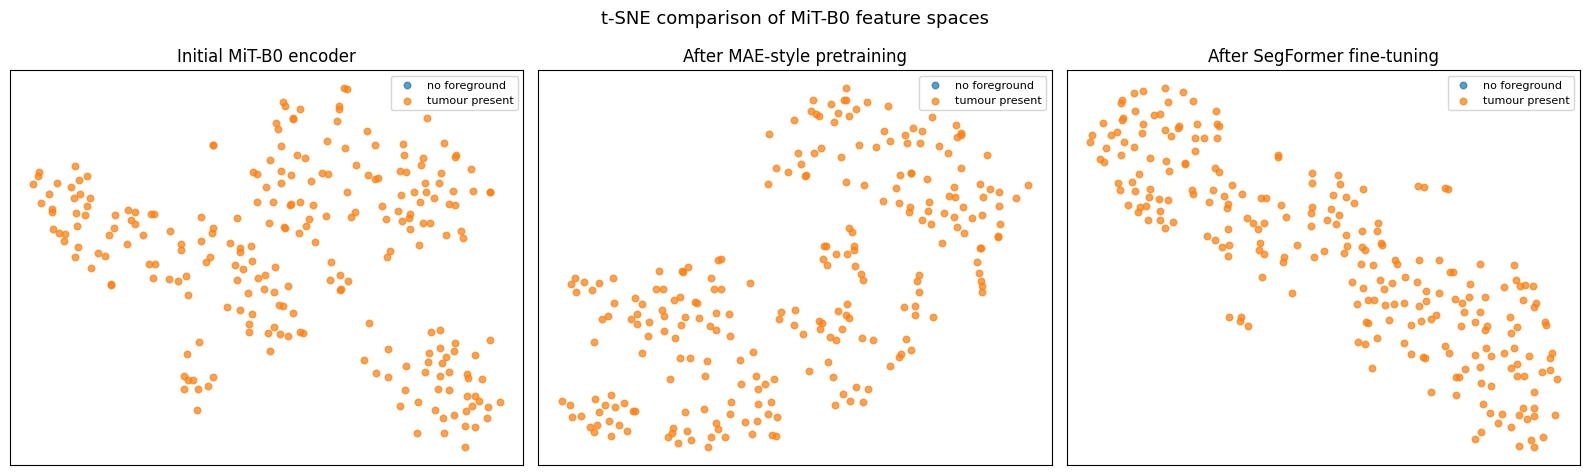

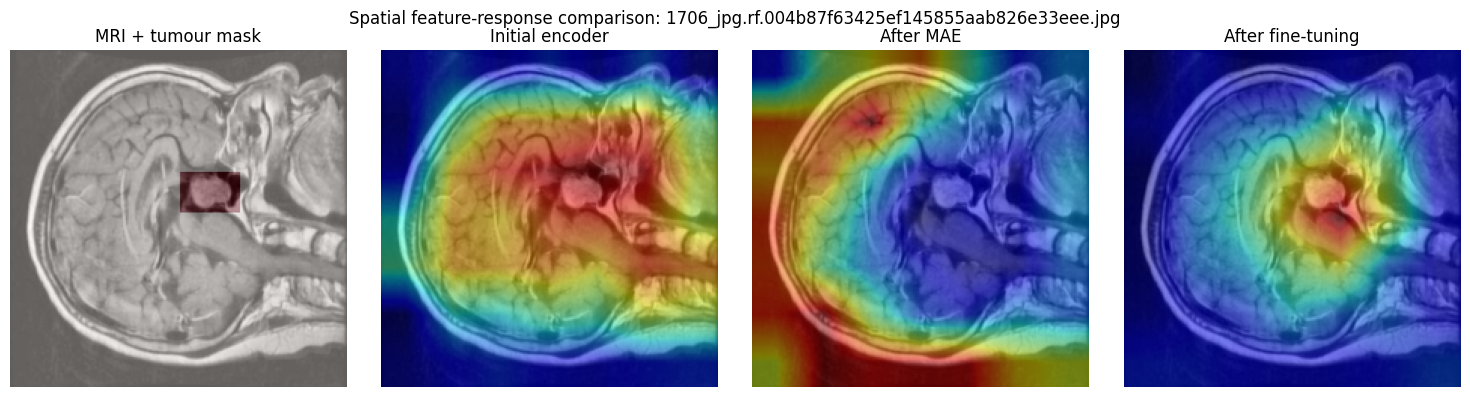

In [14]:

# ============================================================
# 14. Spatial feature-response maps and t-SNE comparison
# ============================================================

initial_encoder = SegformerModel(copy.deepcopy(mae_model.encoder.config)).to(DEVICE)
initial_encoder.load_state_dict(initial_encoder_state)
initial_encoder.eval()

mae_encoder = copy.deepcopy(mae_model.encoder).to(DEVICE)
mae_encoder.eval()

finetuned_encoder = segmentation_model.segformer
finetuned_encoder.eval()

@torch.inference_mode()
def collect_encoder_features(encoder, loader, maximum_samples=240):
    features = []
    labels = []

    for images, masks, _ in loader:
        images = images.to(DEVICE, non_blocking=PIN_MEMORY).contiguous()
        representation = pooled_mit_features(encoder, images).float().cpu().numpy()
        foreground_present = (masks.flatten(1).sum(dim=1) > 0).long().numpy()

        features.append(representation)
        labels.append(foreground_present)

        if sum(part.shape[0] for part in labels) >= maximum_samples:
            break

    return (
        np.concatenate(features, axis=0)[:maximum_samples],
        np.concatenate(labels, axis=0)[:maximum_samples],
    )

initial_features, feature_labels = collect_encoder_features(initial_encoder, feature_loader)
mae_features, _ = collect_encoder_features(mae_encoder, feature_loader)
finetuned_features, _ = collect_encoder_features(finetuned_encoder, feature_loader)

def generate_tsne(features):
    scaled = StandardScaler().fit_transform(features)
    sample_count = scaled.shape[0]
    perplexity = max(2, min(30, sample_count // 4, sample_count - 1))
    return TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        random_state=SEED,
    ).fit_transform(scaled)

tsne_embeddings = [
    generate_tsne(initial_features),
    generate_tsne(mae_features),
    generate_tsne(finetuned_features),
]
titles = [
    "Initial MiT-B0 encoder",
    "After MAE-style pretraining",
    "After SegFormer fine-tuning",
]

figure, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for axis, embedding, title in zip(axes, tsne_embeddings, titles):
    for class_value, label_name in [(0, "no foreground"), (1, "tumour present")]:
        selected = feature_labels == class_value
        axis.scatter(
            embedding[selected, 0],
            embedding[selected, 1],
            s=22,
            alpha=0.72,
            label=label_name,
        )
    axis.set_title(title)
    axis.set_xticks([])
    axis.set_yticks([])
    axis.legend(fontsize=8)

figure.suptitle("t-SNE comparison of MiT-B0 feature spaces", fontsize=13)
figure.tight_layout()
figure.savefig(FIGURE_DIR / "08_tsne_three_stage_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

response_index = positive_test_indices[0] if positive_test_indices else 0
response_image, response_mask, response_name = test_dataset[response_index]
response_batch = response_image.unsqueeze(0).to(DEVICE).contiguous()

@torch.inference_mode()
def create_response_map(encoder, input_batch, output_size):
    feature_grid = final_feature_map(encoder, input_batch)
    response = feature_grid.float().abs().mean(dim=1, keepdim=True)
    response = F.interpolate(response, size=output_size, mode="bilinear", align_corners=False)[0, 0]
    response = response - response.min()
    response = response / (response.max() + 1e-7)
    return response.cpu().numpy()

initial_response = create_response_map(initial_encoder, response_batch, response_mask.shape[-2:])
mae_response = create_response_map(mae_encoder, response_batch, response_mask.shape[-2:])
finetuned_response = create_response_map(finetuned_encoder, response_batch, response_mask.shape[-2:])

base_image = denormalise_image(response_image)

figure, axes = plt.subplots(1, 4, figsize=(15, 4))
axes[0].imshow(base_image)
axes[0].imshow(response_mask.numpy(), cmap="Reds", alpha=0.38, vmin=0, vmax=1)
axes[0].set_title("MRI + tumour mask")

for axis, spatial_map, title in zip(
    axes[1:],
    [initial_response, mae_response, finetuned_response],
    ["Initial encoder", "After MAE", "After fine-tuning"],
):
    axis.imshow(base_image)
    axis.imshow(spatial_map, cmap="jet", alpha=0.48, vmin=0, vmax=1)
    axis.set_title(title)

for axis in axes:
    axis.axis("off")

figure.suptitle(f"Spatial feature-response comparison: {response_name}", fontsize=12)
figure.tight_layout()
figure.savefig(FIGURE_DIR / "09_spatial_feature_response_comparison.png", dpi=180, bbox_inches="tight")
plt.show()


In [15]:

# ============================================================
# 15. Save concise report information for classroom review
# ============================================================

experiment_summary = {
    "course": "CSE 438: Digital Image Processing",
    "instructor": "Dr Md Rifat Ahmmad Rashid",
    "pipeline": "MAE-style masked reconstruction on MiT-B0 followed by SegFormer-B0 segmentation",
    "dataset_root": str(DATA_ROOT),
    "classes": {"0": "background", "1": "tumour region"},
    "device": str(DEVICE),
    "amp_enabled": bool(AMP_ENABLED),
    "encoder_initialisation": mae_model.initialisation_source,
    "mae_epochs": MAE_EPOCHS,
    "segmentation_epochs": SEGMENTATION_EPOCHS,
    "mae_parameters": {
        "mask_ratio": MASK_RATIO,
        "mask_patch_size": MASK_PATCH_SIZE,
    },
    "best_validation_dice": float(best_validation_dice),
    "test_metrics": {key: float(value) for key, value in test_metrics.items()},
    "saved_outputs": {
        "figures": str(FIGURE_DIR),
        "metrics": str(METRIC_DIR),
        "checkpoints": str(CHECKPOINT_DIR),
    },
}

with open(OUTPUT_DIR / "experiment_summary.json", "w", encoding="utf-8") as file:
    json.dump(experiment_summary, file, indent=2)

print(json.dumps(experiment_summary, indent=2))
print("\nSummary comment:")
print(
    "The notebook uses masked reconstruction to pretrain the same MiT-B0 encoder "
    "used by SegFormer. Analyse the result through Dice and IoU, qualitative "
    "prediction errors, response maps, and t-SNE patterns rather than pixel accuracy alone."
)


{
  "course": "CSE 438: Digital Image Processing",
  "instructor": "Dr Md Rifat Ahmmad Rashid",
  "pipeline": "MAE-style masked reconstruction on MiT-B0 followed by SegFormer-B0 segmentation",
  "dataset_root": "/kaggle/input/datasets/pkdarabi/brain-tumor-image-dataset-semantic-segmentation",
  "classes": {
    "0": "background",
    "1": "tumour region"
  },
  "device": "cuda",
  "amp_enabled": true,
  "encoder_initialisation": "pretrained nvidia/mit-b0",
  "mae_epochs": 10,
  "segmentation_epochs": 10,
  "mae_parameters": {
    "mask_ratio": 0.6,
    "mask_patch_size": 16
  },
  "best_validation_dice": 0.7773673664953532,
  "test_metrics": {
    "dice": 0.7714580708430351,
    "iou": 0.6279460656035263,
    "pixel_accuracy": 0.9832362178156147,
    "loss": 0.31275609218411976
  },
  "saved_outputs": {
    "figures": "/kaggle/working/mae_segformer_brain_tumour/figures",
    "metrics": "/kaggle/working/mae_segformer_brain_tumour/metrics",
    "checkpoints": "/kaggle/working/mae_segform


## References

1. He, K., Chen, X., Xie, S., Li, Y., Dollár, P., and Girshick, R. (2022). *Masked Autoencoders Are Scalable Vision Learners*. Proceedings of CVPR, 16000–16009.  
2. Xie, E., Wang, W., Yu, Z., Anandkumar, A., Alvarez, J. M., and Luo, P. (2021). *SegFormer: Simple and Efficient Design for Semantic Segmentation with Transformers*. Advances in Neural Information Processing Systems, 34, 12077–12090.

### Interpretation prompt for students

Compare the reconstruction panels with the final semantic prediction panels. Reconstruction quality alone does not demonstrate tumour localisation. A stronger conclusion requires consistent foreground overlap on held-out masks, interpretable error maps, and feature-response changes that become more aligned with tumour structure after supervised fine-tuning.
